<h2 style="color:navy">Confidance Interval</h2>.

CI is how certain of uncertain our sampling method is

A 95% confidence interval means that if we were to take many, many random samples from the same population and build a confidence interval from each sample, then 95% of those intervals would contain the true population parameter.


<h3 style="color:navy">Comparing  Two Means</h3>.

The CI for the difference of two population means $(\mu_1-\mu2)$ is
$$(\hat{x_{1}}-\hat{x_{2}})\pm t^* \times \sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}$$

Where $t^*$ comes is a Table value and corresponds to the confidence level desired and df = smaller $n_1 -1$ and $n_2 -1$



⠀
⠀
⠀
⠀⠀
⠀⠀
⠀⠀
⠀⠀
⠀⠀
⠀⠀
⠀⠀
⠀
⠀



  



 

In [213]:
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.simplefilter("ignore", category=FutureWarning)

In [138]:
def ci_mean_diff(groupA,groupB,alpha=0.01):
    
    '''
    Function that clcaulate CI for mean difference, 
    and returns 3 data points ci_lower, mean_diff, ci_upper
    '''
    
    mean_diff = np.mean(groupA) - np.mean(groupB)
    se = np.sqrt(np.var(groupA, ddof=1)/len(groupA) + np.var(groupB, ddof=1)/len(groupB))
    
    df = len(groupA) + len(groupB) - 2
    t_crit = stats.t.ppf(1 - alpha/2, df)

    ci_lower = mean_diff - t_crit * se
    ci_upper = mean_diff + t_crit * se
    
    return ci_lower, mean_diff, ci_upper

In [139]:
groupA = np.array([12, 15, 14, 10, 13, 15])
groupB = np.array([10, 11, 9, 12, 8, 10])

ci_mean_diff(groupA, groupB, alpha=0.05)

(0.9822823462777572, 3.166666666666666, 5.351050987055575)

In [148]:

def ci_mean_diff(groupA, groupB, alpha=0.05, plot=True):
    """
    Compute confidence interval for mean difference (independent samples)
    and optionally visualize the results.
    """
    # --- Calculate basic stats ---
    mean_A = np.mean(groupA)
    mean_B = np.mean(groupB)
    mean_diff = mean_A - mean_B

    # Standard error and t-critical
    se = np.sqrt(np.var(groupA, ddof=1)/len(groupA) + np.var(groupB, ddof=1)/len(groupB))
    df = len(groupA) + len(groupB) - 2
    t_crit = stats.t.ppf(1 - alpha/2, df)

    # Confidence interval
    ci_lower = mean_diff - t_crit * se
    ci_upper = mean_diff + t_crit * se

    # --- Plot ---
    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3), width_ratios=(2, 3))

        # 1️⃣ Plot group means with their 95% CI
        std_errors = [np.std(groupA, ddof=1)/np.sqrt(len(groupA)),
                      np.std(groupB, ddof=1)/np.sqrt(len(groupB))]
        ci_lower_means = [mean_A - t_crit*std_errors[0], mean_B - t_crit*std_errors[1]]
        ci_upper_means = [mean_A + t_crit*std_errors[0], mean_B + t_crit*std_errors[1]]

        ax1.errorbar(['Group A', 'Group B'], [mean_A, mean_B],
                     yerr=[[mean_A - ci_lower_means[0], mean_B - ci_lower_means[1]],
                           [ci_upper_means[0] - mean_A, ci_upper_means[1] - mean_B]],
                     fmt='o', capsize=5, markersize=8, color='#1f77b4')
        ax1.set_ylabel('Mean Value')
        ax1.set_title(f'Mean Estimates with {(1-alpha)*100:.0f}% CI')
        ax1.grid(True, alpha=0.3)

        # Plot mean difference with multiple confidence levels
        confidence_levels = [80, 90, 95, 99, 99.9]
        positions = np.linspace(0, 1, len(confidence_levels))

        for y, ci in zip(positions, confidence_levels):
            alpha_level = 1 - ci / 100

            ci_lower2, diff2, ci_upper2 = ci_mean_diff(groupA, groupB, alpha=alpha_level, plot=False)

            # color logic
            color = '#1f77b4' if (ci_lower2 > 0 or ci_upper2 < 0) else '#d62728'

            ax2.errorbar(diff2, [y],
                         xerr=[[diff2 - ci_lower2], [ci_upper2 - diff2]],
                         fmt='o', color=color, capsize=5, markersize=6)

        ax2.axvline(x=0, color='black', linestyle='--', alpha=0.6, label='No difference')
        ax2.set_xlabel('Mean Difference (A - B)')
        ax2.set_ylabel('Confidence Levels')
        ax2.set_yticks(positions)
        ax2.set_yticklabels([f"{c:.1f}%" for c in confidence_levels])
        ax2.set_title('Effect Size Across Confidence Levels')
        ax2.legend(loc='lower right')

        # Styling
        ax1.set_facecolor("#edeff2")
        ax2.set_facecolor("#edeff2")
        plt.grid(True, linestyle='--', alpha=0.5, color='black', linewidth=0.4)
        plt.tight_layout()
        plt.show()

    else:
        return ci_lower, mean_diff, ci_upper


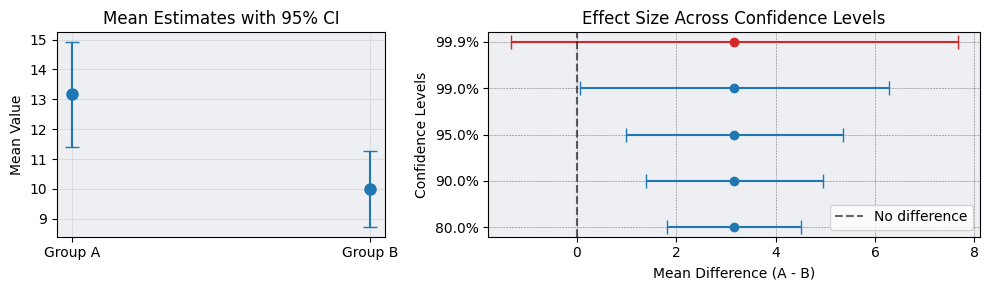

In [147]:
ci_mean_diff(groupA, groupB, alpha=0.05)

<h3 style="color:navy">Comparing Two Proportions</h3>

The CI for the difference of two population proportions $(p_1-p_2)$ is
$$(\hat{p}_1-\hat{p}_2)\pm z^* \times \sqrt{\frac{\hat{p}_1(1-\hat{p}_1)}{n_1}+\frac{\hat{p}_2(1-\hat{p}_2)}{n_2}}$$

Where $z^*$ comes from the standard normal distribution and corresponds to the confidence level desired.


In [131]:
def ci_prop_diff(conversions_A, visitors_A, conversions_B, visitors_B, alpha=0.05, plot=True):
    """
    Calculate and optionally plot confidence intervals for difference in proportions (A/B test)
    """
    # Conversion rates
    rate_A = conversions_A / visitors_A
    rate_B = conversions_B / visitors_B
    
    # Difference
    diff = rate_B - rate_A
    
    # Standard errors
    se_A = np.sqrt(rate_A * (1 - rate_A) / visitors_A)
    se_B = np.sqrt(rate_B * (1 - rate_B) / visitors_B)
    se_diff = np.sqrt(se_A**2 + se_B**2)
    
    # Critical value
    z_score = stats.norm.ppf(1 - alpha / 2)
    
    # Confidence interval
    ci_lower = round(diff - z_score * se_diff, 4)
    ci_upper = round(diff + z_score * se_diff, 4)
  
    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3), width_ratios=(2, 3))

        # --- Plot 1: Conversion rates ---
        rates = np.array([rate_A, rate_B])
        visitors = np.array([visitors_A, visitors_B])
        std_errors = np.sqrt(rates * (1 - rates) / visitors)
        ci_lower_rates = rates - z_score * std_errors
        ci_upper_rates = rates + z_score * std_errors

        ax1.errorbar(['Group A', 'Group B'], rates,
                     yerr=[rates - ci_lower_rates, ci_upper_rates - rates],
                     fmt='o', color='#1f77b4', capsize=5, markersize=8)
        
        ax1.set_title(f'Conversion Rates with {(1-alpha)*100:.0f}% CI')
        ax1.set_ylabel('Conversion Rate')
        ax1.set_facecolor("#edeff2")
        ax1.grid(True, alpha=0.3)

        # --- Plot 2: Effect size (difference) with multiple CIs ---
        confidence_levels = [80, 90, 95, 99, 99.9]
        positions = np.linspace(0, 1, len(confidence_levels))  # equal vertical spacing

        for y, ci in zip(positions, confidence_levels):
            alpha_level = 1 - ci / 100
            ci_lower2, diff2, ci_upper2 = ci_prop_diff(conversions_A, visitors_A, conversions_B, visitors_B, alpha=alpha_level, plot=False)

            # Change color if interval crosses 0
            if ci_lower2 <= 0 <= ci_upper2:
                color = '#d62728'  # red (not significant)
            else:
                color = '#1f77b4'  # (significant)

            ax2.errorbar(diff2, [y],
                         xerr=[[diff2 - ci_lower2], [ci_upper2 - diff2]],
                         fmt='o', color=color,
                         capsize=5, markersize=6)

        # Decorations
        ax2.axvline(x=0, color='black', linestyle='--', alpha=0.6, label='No effect')
        ax2.set_xlabel('Absolute Difference (B - A)')
        ax2.set_ylabel('Confidence Levels')
        ax2.set_yticks(positions)
        ax2.set_yticklabels([f"{c:.1f}%" for c in confidence_levels])
     
        ax2.set_title('Effect Size with Confidence Intervals')
        ax2.axvline(x=0, color='red', linestyle='--', alpha=0.7)
        ax2.set_facecolor("#edeff2")

        
        plt.grid(True, linestyle='--', alpha=0.7, color= 'black',linewidth =0.4)
        plt.tight_layout()


    else:
        return ci_lower, diff, ci_upper

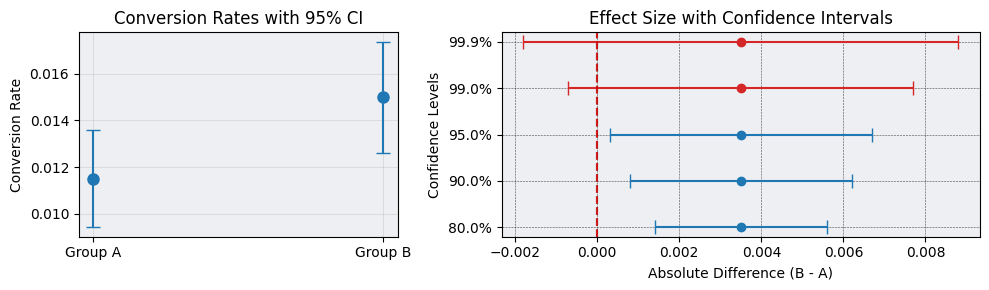

In [135]:
# Example usage
conversions_A = 115
visitors_A = 10000
conversions_B = 150
visitors_B = 10000

results = ci_prop_diff(conversions_A, visitors_A, conversions_B, visitors_B,0.05)
results


<h3 style="color:navy">Confidence Interval for Difference Between Two Medians</h3>

Telecommunications Repair Time Verizon is the main regional telecommunications company (Inclusive Local Exchange Carrier, ILEC) in the western United States. In this regard, this company is obliged to provide telecommunications equipment repair service not only for its customers, but also for customers of other local telecommunications companies (Competing Local Exchange Carriers, CLEC). At the same time, in cases where the equipment repair time for customers of other companies is significantly higher than for their own, Verizon may be fined..

In [154]:
data=pd.read_csv('https://raw.githubusercontent.com/V23KTOR/Study/refs/heads/main/Statistics/data/verizon.txt',sep='\t')
data.sample(5)

,Time,Group
662,12.87,ILEC
552,16.40,ILEC
1392,2.58,ILEC
1530,22.25,ILEC
68,54.28,ILEC


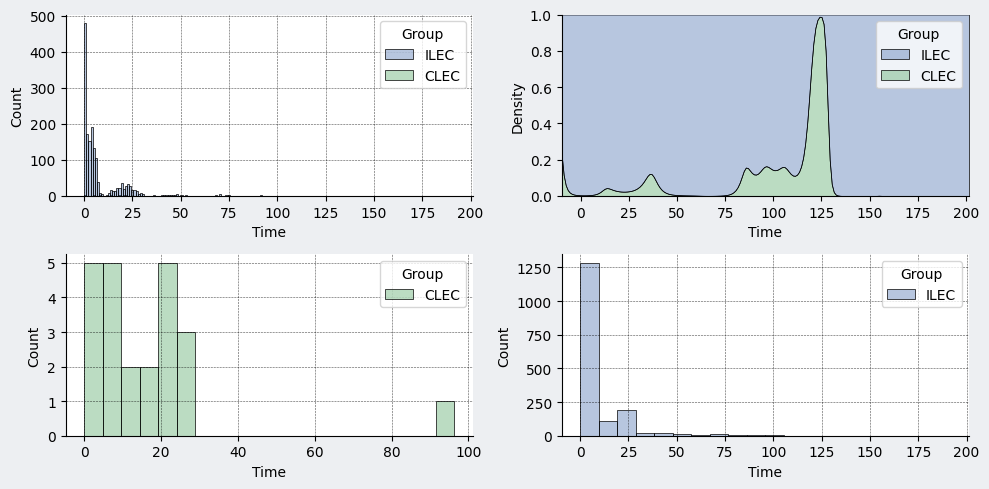

In [214]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10, 5))

sns.histplot(data=data,
             x='Time',
             palette=['#4C72B0', '#55A868'],
             hue='Group',
             alpha=0.4,
             linewidth=0.5,
             ax=ax1
             #bins = 20
              )

sns.kdeplot(data=data,
            x='Time',
            hue='Group',
            multiple="fill",
            fill=True, 
            #common_norm=False,
            palette=['#4C72B0', '#55A868'],
            alpha=0.4,
            linewidth=0.5,
            ax=ax2
            )


sns.histplot(data[data.Group == 'CLEC'],
             x='Time',
             palette=['#55A868'],
             hue='Group',
             alpha=0.4,
             linewidth=0.5,
             ax=ax3,
             bins = 20
              )

sns.histplot(data[data.Group == 'ILEC'],
             x='Time',
             palette=['#4C72B0'],
             hue='Group',
             alpha=0.4,
             linewidth=0.5,
             ax=ax4,
             bins = 20
              )

sns.despine()

fig.patch.set_facecolor('#edeff2')
ax1.grid(True, linestyle='--', alpha=0.7, color= 'black',linewidth =0.4)
ax3.grid(True, linestyle='--', alpha=0.7, color= 'black',linewidth =0.4)
ax4.grid(True, linestyle='--', alpha=0.7, color= 'black',linewidth =0.4)

plt.tight_layout()
plt.show()

<h5 style="color:navy">Bootstrap</h5>

In [156]:
def get_bootstrap_samples(data, n_samples):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples
    
def stat_intervals(stat, alpha):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

In [157]:
ilec_time = data[data.Group == 'ILEC'].Time.values
clec_time = data[data.Group == 'CLEC'].Time.values


<h5 style="color:navy">Interval estimation of the median</h5>

In [159]:
np.random.seed(0)

ilec_median_scores = list(map(np.median, get_bootstrap_samples(ilec_time, 1000)))
clec_median_scores = list(map(np.median, get_bootstrap_samples(clec_time, 1000)))

print("95% confidence interval for the ILEC median repair time:",  stat_intervals(ilec_median_scores, 0.05))
print("95% confidence interval for the CLEC median repair time:",  stat_intervals(clec_median_scores, 0.05))

95% confidence interval for the ILEC median repair time: [3.18    3.82525]
95% confidence interval for the CLEC median repair time: [ 5.79125 20.     ]



<h5 style="color:navy">Interval estimation of the median</h5>

In [161]:
print("difference between medians:", np.median(clec_time) - np.median(ilec_time))

difference between medians: 10.74


In [162]:
delta_median_scores = list(map(lambda x: x[1] - x[0], zip(ilec_median_scores, clec_median_scores)))

In [215]:
print("95% confidence interval for the difference between medians",  stat_intervals(delta_median_scores, 0.05))

95% confidence interval for the difference between medians [ 2.04975 16.63   ]
